In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# EDA

In [2]:
df = pd.read_csv("/Users/adityagupta/Desktop/ML/MinorProjects/D2C/Dataset.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.shape

(3900, 18)

In [4]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [7]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [8]:
numeric_cols = df.select_dtypes(include=[np.number,np.float64]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

Customer ID
count    3900.000000
mean     1950.500000
std      1125.977353
min         1.000000
25%       975.750000
50%      1950.500000
75%      2925.250000
max      3900.000000
Name: Customer ID, dtype: float64


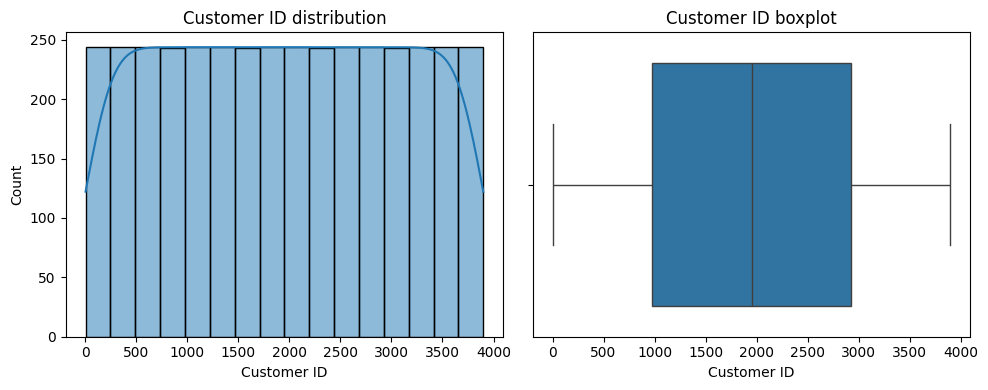

Age
count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64


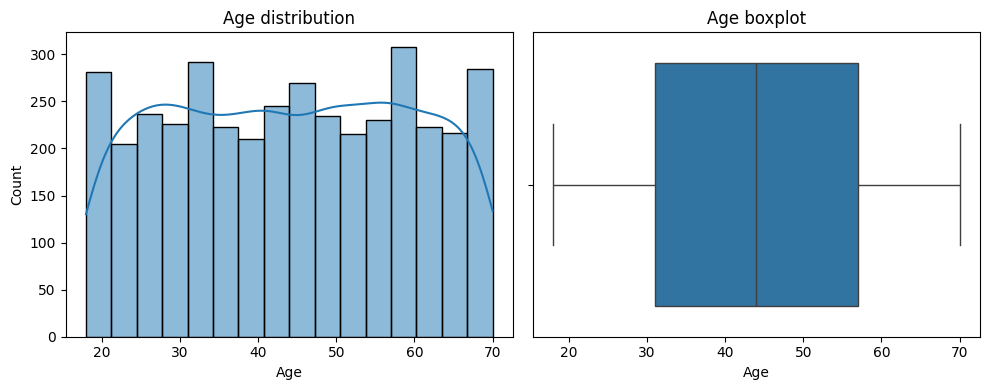

Purchase Amount (USD)
count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: Purchase Amount (USD), dtype: float64


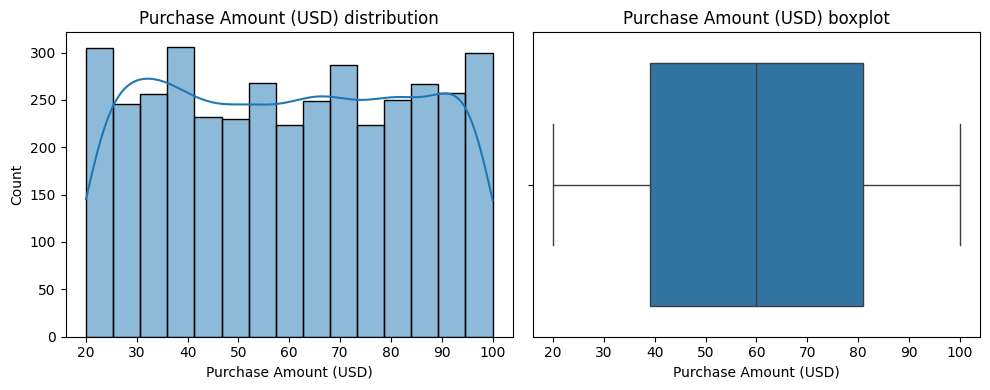

Review Rating
count    3863.000000
mean        3.750065
std         0.716983
min         2.500000
25%         3.100000
50%         3.800000
75%         4.400000
max         5.000000
Name: Review Rating, dtype: float64


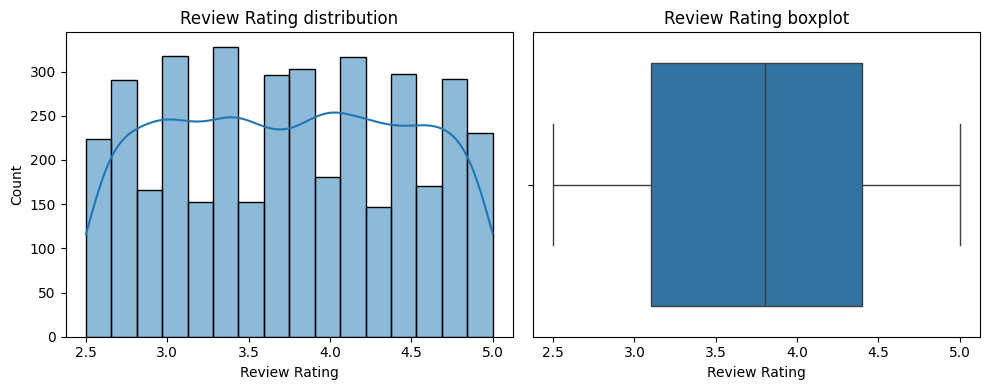

Previous Purchases
count    3900.000000
mean       25.351538
std        14.447125
min         1.000000
25%        13.000000
50%        25.000000
75%        38.000000
max        50.000000
Name: Previous Purchases, dtype: float64


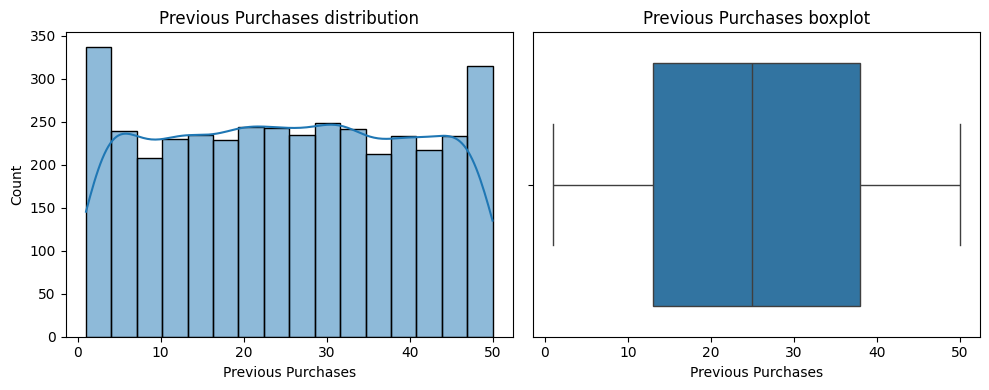

In [9]:
for col in numeric_cols:
    print(col)
    print(df[col].describe())

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True)
                                           
    plt.title(f"{col} distribution")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f"{col} boxplot")

    plt.tight_layout()
    plt.show()

Gender
Male      2652
Female    1248
Name: count, dtype: int64


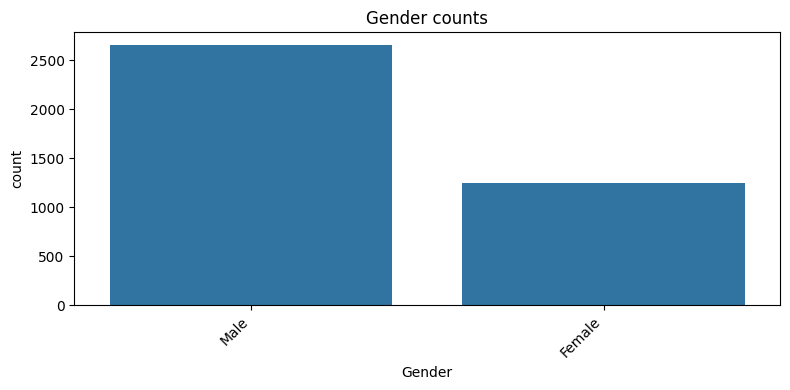

Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64


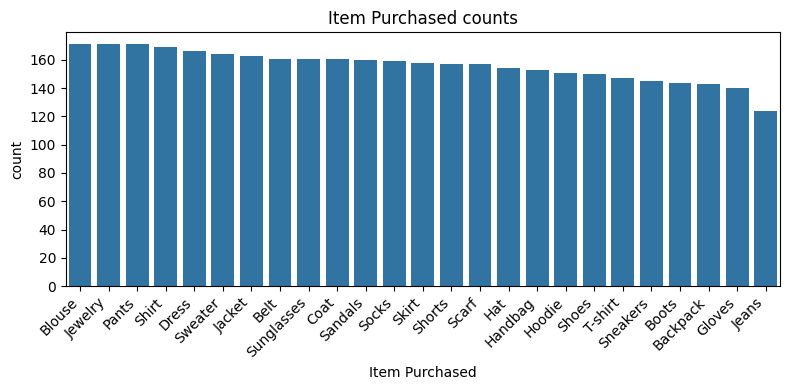

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


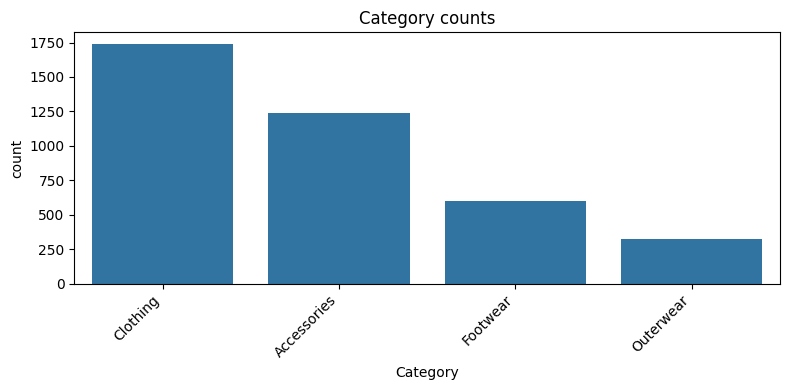

Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
Nebraska          87
New York          87
Nevada            87
Maryland          86
Delaware          86
Vermont           85
Louisiana         84
North Dakota      83
Missouri          81
West Virginia     81
New Mexico        81
Mississippi       80
Indiana           79
Georgia           79
Kentucky          79
Arkansas          79
North Carolina    78
Connecticut       78
Virginia          77
Ohio              77
Tennessee         77
Texas             77
Maine             77
South Carolina    76
Colorado          75
Oklahoma          75
Wisconsin         75
Oregon            74
Pennsylvania      74
Washington        73
Michigan          73
Alaska            72
Massachusetts     72
Wyoming           71
Utah              71
New Hampshire     71
South Dakota      70
Iowa              69
Florida           68
New Jersey        67
Hawaii            65
Ariz

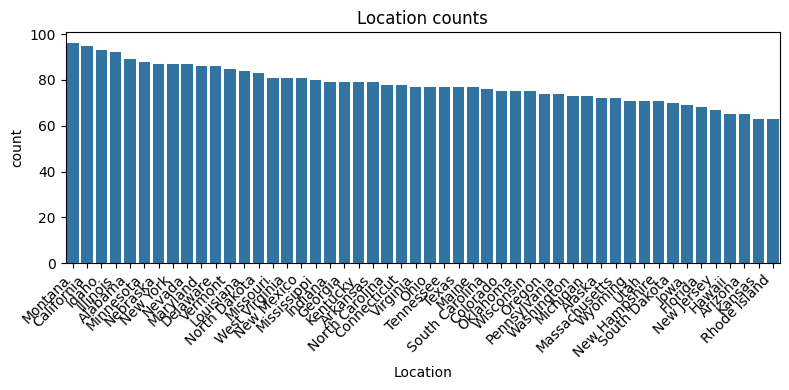

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64


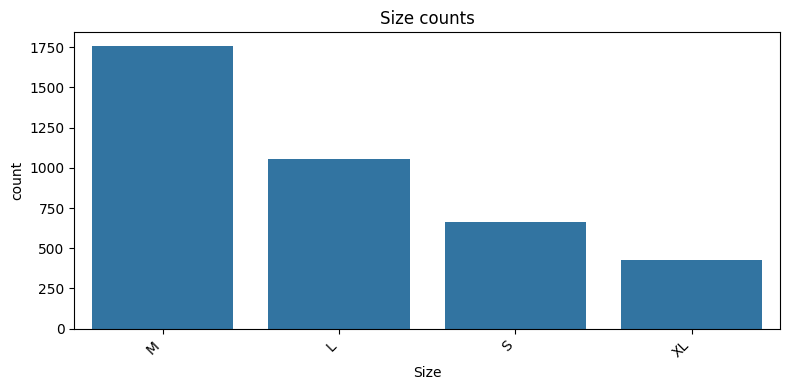

Color
Olive        177
Yellow       174
Silver       173
Teal         172
Green        169
Black        167
Cyan         166
Violet       166
Gray         159
Maroon       158
Orange       154
Charcoal     153
Pink         153
Magenta      152
Blue         152
Purple       151
Peach        149
Red          148
Beige        147
Indigo       147
Lavender     147
Turquoise    145
White        142
Brown        141
Gold         138
Name: count, dtype: int64


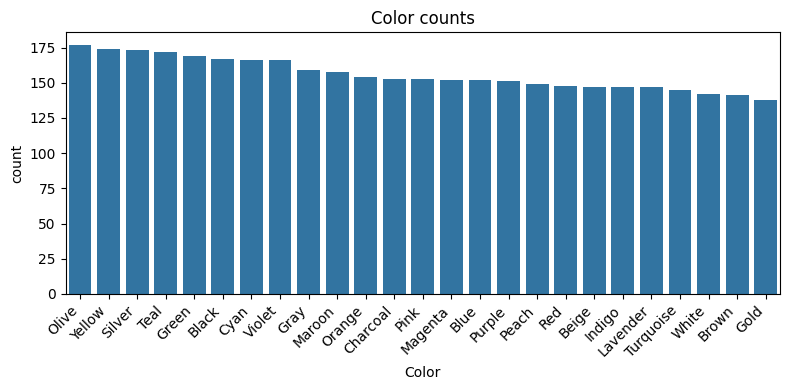

Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64


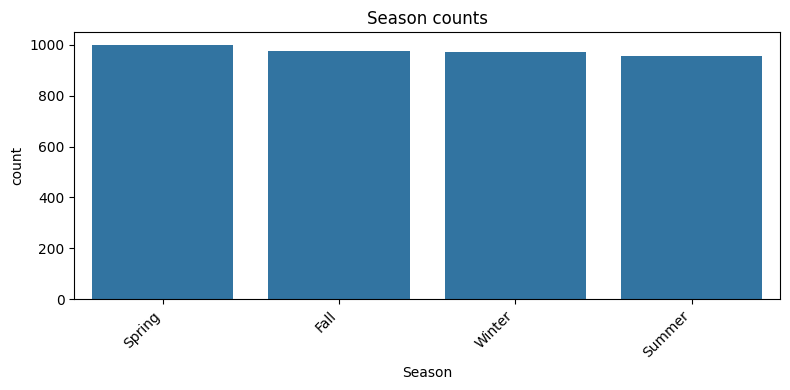

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64


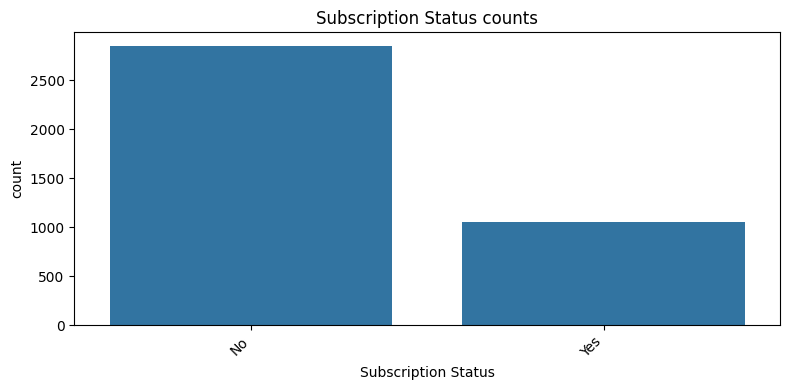

Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64


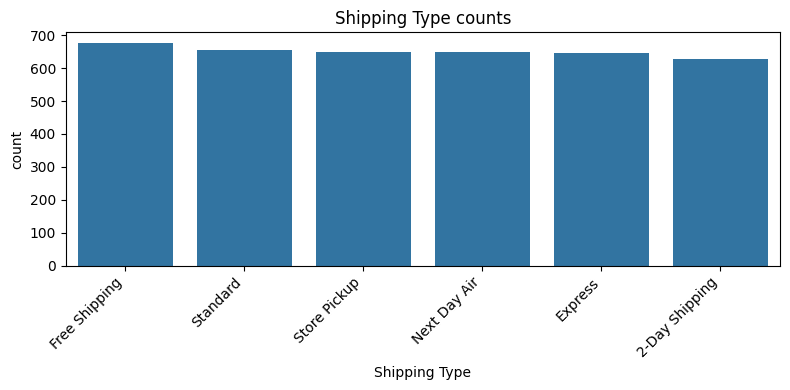

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64


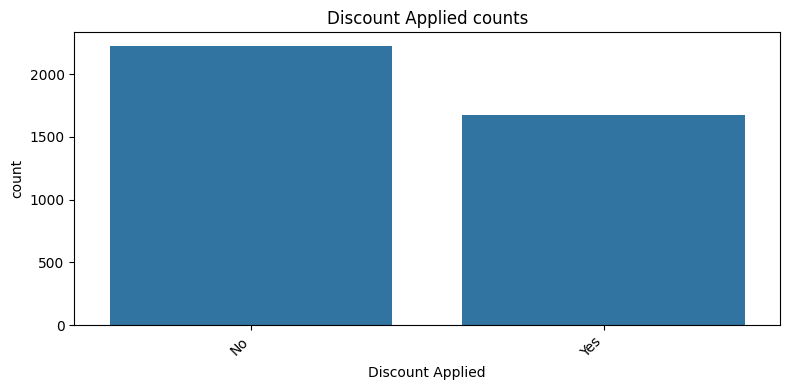

Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64


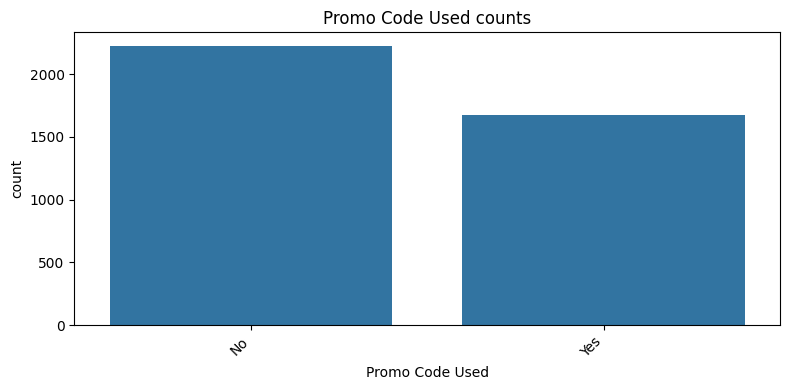

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


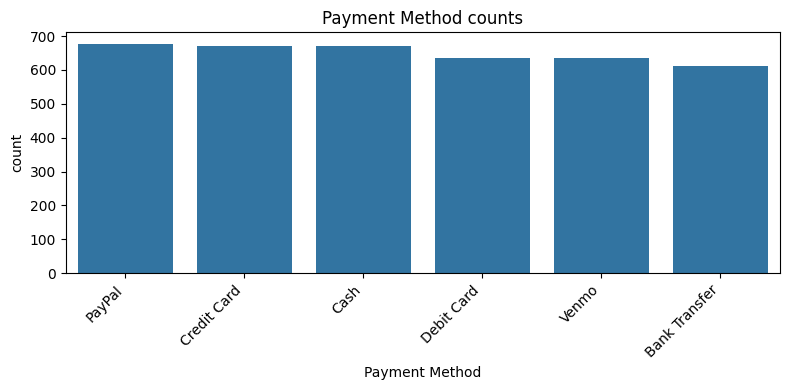

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64


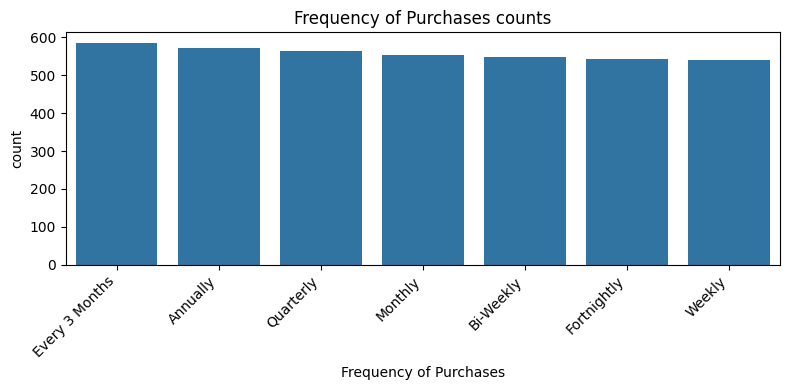

In [10]:
for col in cat_cols:
    print(df[col].value_counts(dropna=False))

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"{col} counts")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [11]:
corr_df = df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].copy()

In [12]:
corr_df['Is_Subscribed'] = df['Subscription Status'].map({'Yes': 1, 'No': 0})
corr_df['Used_Discount'] = df['Discount Applied'].map({'Yes': 1, 'No': 0})
corr_df['Used_Promo'] = df['Promo Code Used'].map({'Yes': 1, 'No': 0})

In [13]:
correlation_matrix = corr_df.corr()

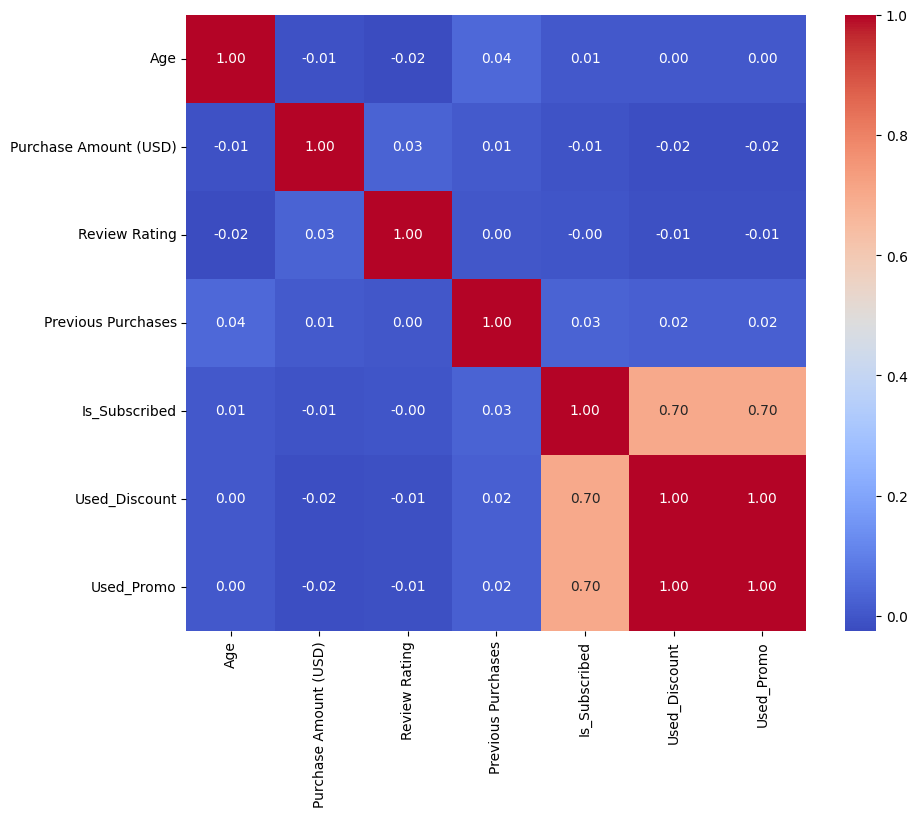

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Comprehensive Correlation Matrix Heatmap')
plt.show()

In [15]:
df['Promo_Dependent'] = df['Discount Applied']

In [16]:
top_locations = df['Location'].value_counts().nlargest(15).index

filtered_df = df[df['Location'].isin(top_locations)]

avg_spend = filtered_df.groupby('Location')['Purchase Amount (USD)'].mean()

promo_usage = filtered_df.groupby('Location')['Promo_Dependent'].apply(lambda x: (x == 'Yes').mean() * 100)

In [17]:
geo_data = pd.DataFrame({
    'Avg_Spend': avg_spend,
    'Promo_Usage_Percent': promo_usage
}).reset_index()

In [18]:
geo_data.head()

,Location,Avg_Spend,Promo_Usage_Percent
0,Alabama,59.112360,40.449438
1,California,59.000000,42.105263
2,Delaware,55.325581,45.348837
3,Idaho,60.075269,40.860215
4,Illinois,61.054348,40.217391


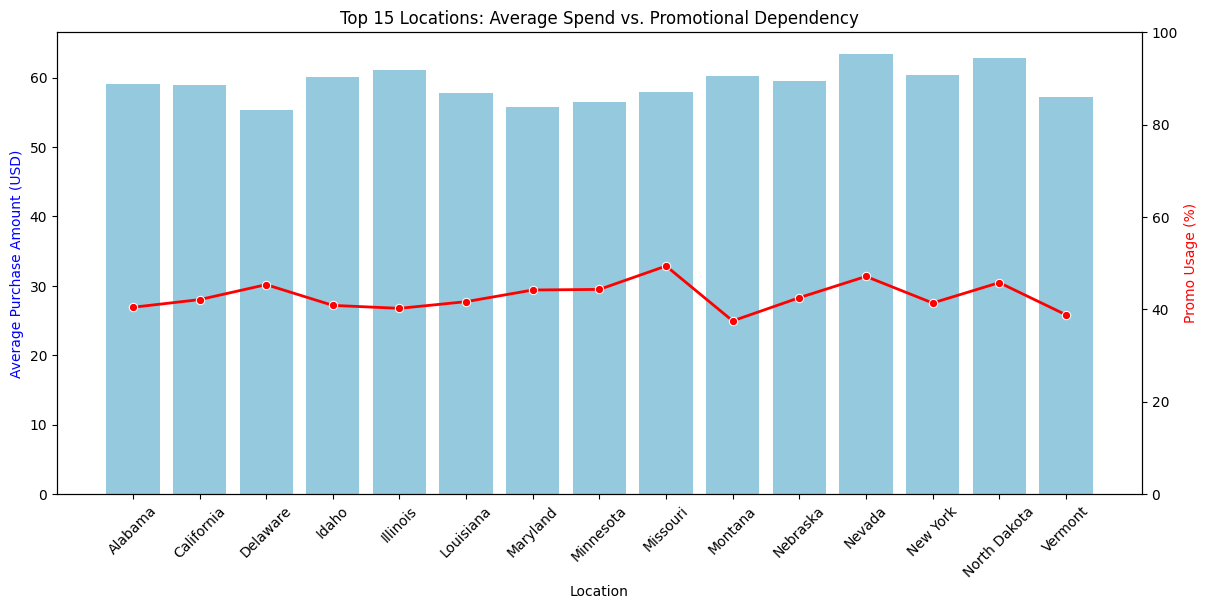

In [19]:
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.barplot(data=geo_data, x='Location', y='Avg_Spend', color='skyblue', ax=ax1)
ax1.set_ylabel('Average Purchase Amount (USD)', color='blue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=geo_data, x='Location', y='Promo_Usage_Percent', color='red', marker='o', ax=ax2, linewidth=2)
ax2.set_ylabel('Promo Usage (%)', color='red')
ax2.set_ylim(0, 100)

plt.title('Top 15 Locations: Average Spend vs. Promotional Dependency')
plt.show()

In [20]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'Promo_Dependent'],
      dtype='object')

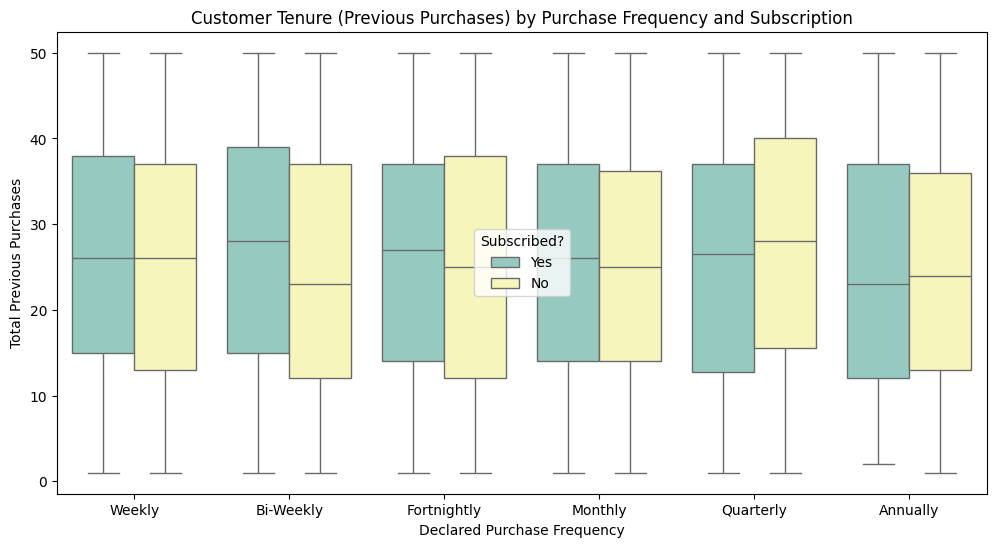

In [21]:
plt.figure(figsize = (12,6))

sns.boxplot(data=df, 
    x='Frequency of Purchases', 
    y='Previous Purchases', 
    hue='Subscription Status',
    palette='Set3',
    order=['Weekly', 'Bi-Weekly', 'Fortnightly', 'Monthly', 'Quarterly', 'Annually']
)


plt.title('Customer Tenure (Previous Purchases) by Purchase Frequency and Subscription')
plt.xlabel('Declared Purchase Frequency')
plt.ylabel('Total Previous Purchases')
plt.legend(title='Subscribed?')
plt.show()

# Feature Engineering

In [22]:
# Combining both discount related features 
df['Promo_Dependent'] = np.where(
    (df['Discount Applied'] == 'Yes') | (df['Promo Code Used'] == 'Yes'), 
    'Yes', 'No')

In [23]:
# Defining loyalty on how often they buy and how many past purchases they have
df['Loyalty_def_A'] = np.where(
    (df['Frequency of Purchases'].isin(['Weekly', 'Bi-Weekly', 'Fortnightly'])) & 
    (df['Previous Purchases'] > 30), 
    'Loyal', 'Standard'
)

In [24]:
print(df['Purchase Amount (USD)'].mean())
print(df['Purchase Amount (USD)'].max())
print(df['Purchase Amount (USD)'].min(), "\n")
print(df['Review Rating'].mean())
print(df['Review Rating'].max())
print(df['Review Rating'].min())

59.76435897435898
100
20 

3.750064716541548
5.0
2.5


In [25]:
# Defining loyalty by how much they spend and how happy they are, regardless of frequency.
df['Loyalty_def_B'] = np.where(
    (df['Purchase Amount (USD)'] > 75) & 
    (df['Review Rating'] >= 4.0) & 
    (df['Subscription Status'] == 'Yes'), 
    'Loyal', 'Standard'
)

In [26]:
df.groupby('Loyalty_def_B')['Purchase Amount (USD)'].mean()

Loyalty_def_B
Loyal       87.911565
Standard    58.661871
Name: Purchase Amount (USD), dtype: float64

In [27]:
# customers who buy at full price without needing promotional triggers.
df['Loyalty_def_C_organic'] = np.where(
    (df['Previous Purchases'] > 25) & 
    (df['Review Rating'] >= 4.0) & 
    (df['Promo_Dependent'] == 'No'), 
    'Organic Loyal', 'Standard'
)

In [28]:
df['Loyalty_def_C_organic'].value_counts()

Loyalty_def_C_organic
Standard         3418
Organic Loyal     482
Name: count, dtype: int64

In [29]:
df['Frequency of Purchases'].value_counts()

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

In [30]:
# Defining loyalty by high spend volume and regular purchase frequency, regardless of promo usage.
df['Loyalty_def_D_Whale'] = np.where(
    (df['Frequency of Purchases'].isin(['Weekly', 'Bi-Weekly', 'Fortnightly', 'Monthly'])) & 
    (df['Purchase Amount (USD)'] >= 80), 
    'Whale', 'Standard'
)

In [32]:
df['Loyalty_def_D_Whale'].value_counts()

Loyalty_def_D_Whale
Standard    3331
Whale        569
Name: count, dtype: int64

In [33]:
df['Shipping Type'].value_counts()

Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64

In [34]:
df['Subscription Status'].value_counts()

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

In [35]:
# defining loyalty through formal commitment (that is subscriptions) and a willingness to pay for premium services (shipping) on a regular basis(frequency of purchase)
df['Loyalty_def_E_Premium'] = np.where(
    (df['Subscription Status'] == 'Yes') & 
    (df['Shipping Type'].isin(['Next Day Air', 'Express'])) & 
    (df['Frequency of Purchases'].isin(['Weekly', 'Bi-Weekly', 'Monthly'])), 
    'Premium Loyal', 'Standard'
)

In [36]:
df['Loyalty_def_E_Premium'].value_counts()

Loyalty_def_E_Premium
Standard         3745
Premium Loyal     155
Name: count, dtype: int64

In [38]:
# printing count of customers by various value counts

print("Definition A (Frequency & Tenure):")
print(df['Loyalty_def_A'].value_counts(), "\n")

print("Definition B (Value & Satisfaction):")
print(df['Loyalty_def_B'].value_counts(), "\n")

print("Definition C (Organic Advocate - No Promos):")
print(df['Loyalty_def_C_organic'].value_counts(),"\n")

print("Definition D (High-Velocity Whale):")
print(df['Loyalty_def_D_Whale'].value_counts(), "\n")

print("Definition E (Premium Engager):")
print(df['Loyalty_def_E_Premium'].value_counts(), "\n")

Definition A (Frequency & Tenure):
Loyalty_def_A
Standard    3252
Loyal        648
Name: count, dtype: int64 

Definition B (Value & Satisfaction):
Loyalty_def_B
Standard    3753
Loyal        147
Name: count, dtype: int64 

Definition C (Organic Advocate - No Promos):
Loyalty_def_C_organic
Standard         3418
Organic Loyal     482
Name: count, dtype: int64 

Definition D (High-Velocity Whale):
Loyalty_def_D_Whale
Standard    3331
Whale        569
Name: count, dtype: int64 

Definition E (Premium Engager):
Loyalty_def_E_Premium
Standard         3745
Premium Loyal     155
Name: count, dtype: int64 



# Anlaysis using SQL

#### For our core SQL analysis, we are dropping the other loyalty definitions to focus exclusively on the contrast between Definition A and Definition C.

#### Loyalty_def_A (Frequency Loyal): Represents our baseline. These are customers who buy often, but as our EDA showed, many still rely heavily on discounts

#### Loyalty_def_C (Organic Advocate): Represents our ideal target. These are high value customers who buy purely based on brand affinity and satisfaction, without needing promotional triggers

In [40]:
df2 = df.drop(columns=['Loyalty_def_B', 'Loyalty_def_D_Whale', 'Loyalty_def_E_Premium'])

In [59]:
import sqlite3

conn = sqlite3.connect(':memory:')

In [60]:
# loading the final dataframe in sql 
df2.to_sql('customers', conn, index=False, if_exists='replace')

3900

In [98]:
query_1 = """
select 
    'Loyal Customers(Def A)' as Loyalty_Segment,
    count("Customer ID") as Total_Customers,
    round(avg("Purchase Amount (USD)"),2) as Avg_Spend_Per_Order,
    sum("Purchase Amount (USD)") as Total_Revenue_Generated
from customers
where Loyalty_def_A = 'Loyal'

union all 

select 
    'Organic Customers(Def C)' AS Loyalty_Segment,
    count("Customer ID") as Total_Customers,
    round(avg("Purchase Amount (USD)"),2) as Avg_Spend_Per_Order,
    sum("Purchase Amount (USD)") as Total_Revenue_Generated
from customers
where Loyalty_def_C_organic = 'Organic Loyal'
"""

pd.read_sql_query(query_1, conn)

,Loyalty_Segment,Total_Customers,Avg_Spend_Per_Order,Total_Revenue_Generated
0,Loyal Customers(Def A),648,59.64,38647
1,Organic Customers(Def C),482,61.66,29721


#### Insight:Definition A and Definition C show nearly same average spent. 
#### This shows that frequent buyers are not usually high value buyers per transaction 

In [99]:
query_2 = """
select 
    Category,
    sum(case
            when Loyalty_def_C_organic = 'Organic Loyal' then 1 
            else 0 
            end) as Organic_Cust_Count
from customers
group by Category
"""
pd.read_sql_query(query_2, conn)

,Category,Organic_Cust_Count
0,Accessories,148
1,Clothing,216
2,Footwear,77
3,Outerwear,41


#### Insight: Clothing and Accessories drive the highest volume of organic customers

In [101]:
query_3 = """
select 
    Location,
    count("Customer ID") as Total_Customers,
    round(avg("Purchase Amount (USD)"), 2) as Avg_Spend,
    round(sum(case
                when Promo_Dependent = 'Yes' then 1 
                else 0 
                end) * 100.0 / COUNT(*), 1) as Promo_Dependency_Percentage
from customers
group by Location
having Total_Customers > 50
order by Avg_Spend desc, Promo_Dependency_Percentage asc
limit 10
"""
pd.read_sql_query(query_3, conn)

,Location,Total_Customers,Avg_Spend,Promo_Dependency_Percentage
0,Alaska,72,67.60,40.3
1,Pennsylvania,74,66.57,44.6
2,Arizona,65,66.55,33.8
3,West Virginia,81,63.88,49.4
4,Nevada,87,63.38,47.1
5,Washington,73,63.33,43.8
6,North Dakota,83,62.89,45.8
7,Virginia,77,62.88,37.7
8,Utah,71,62.58,46.5
9,Michigan,73,62.10,39.7


#### Insight: Geographic clusters like Massachusetts and Rhode Island show higher average spend but also higher promo dependency, indicating sensitivity to discounts in these regions

In [106]:
query_4="""
select
    Loyalty_def_A,
    count("Customer ID") as Total,
    round(sum(case
                when Promo_Dependent = 'Yes' then 1 
                else 0
                end) * 100.0 / COUNT(*), 1) as Promo_Percentage,
    round(avg("Purchase Amount (USD)"), 2) as Avg_Spend
from customers
group by Loyalty_def_A;"""

pd.read_sql_query(query_4, conn)

,Loyalty_def_A,Total,Promo_Percentage,Avg_Spend
0,Loyal,648,46.1,59.64
1,Standard,3252,42.4,59.79


#### Insight: Our Loyal segment (Def A) has a 46.1% promotional dependency, which is higher than the Standard segment. This means we are giving more discounts/providing more promitional activity to our frequent buyers

In [114]:
query_5 = """
select 
    round(avg(Age), 1) as Avg_Age,
    "Payment Method",
    "Shipping Type",
    Category,
    COUNT(*) AS Count,
    round(avg("Purchase Amount (USD)"), 2) as Avg_Spend,
    round(avg("Review Rating"), 2) as Avg_Rating
from customers
where Loyalty_def_A = 'Loyal' and Loyalty_def_C_organic = 'Organic Loyal'
group by "Payment Method", "Shipping Type", Category
order by Count desc
limit 10;"""

pd.read_sql_query(query_5, conn)

,Avg_Age,Payment Method,Shipping Type,Category,Count,Avg_Spend,Avg_Rating
0,44.4,Debit Card,Express,Clothing,5,59.60,4.48
1,45.0,Cash,2-Day Shipping,Footwear,4,57.75,4.53
2,44.0,Credit Card,Next Day Air,Accessories,4,69.25,4.38
3,37.5,Credit Card,Next Day Air,Clothing,4,72.25,4.68
4,50.8,PayPal,Next Day Air,Clothing,4,55.75,4.70
5,25.7,Bank Transfer,Store Pickup,Clothing,3,60.67,4.17
6,52.7,Cash,Express,Clothing,3,72.33,4.13
7,39.3,Cash,Free Shipping,Clothing,3,55.33,4.73
8,47.3,Credit Card,2-Day Shipping,Clothing,3,75.67,4.47
9,54.7,Credit Card,Express,Accessories,3,62.67,4.43


#### Insight: Our Ideal Customer are older demographic (Age 37-52) using Credit Cards and Next Day Air/Express shipping, demonstrating a clear willingness to pay for premium convenience over discounts.